# The model, in plain language

Runs after `04_models.ipynb`. Reads `../data/clean.csv` and `../data/profiles.csv`.

`04` settled the statistics: one shared model for everyone, with a curved term for experience.
This notebook does not change that model. It changes what comes out of it, so the result can be
read by someone who has never seen a regression table.

Three changes: raw units instead of standardised ones, the curved term printed as a small table of
marginal effects instead of a coefficient, and accuracy reported as typical error in minutes
instead of R^2.

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/clean.csv').merge(pd.read_csv('../data/profiles.csv'), on='runner_id')
d = df[df.dnf == 0].copy()

PRED = ['running_experience_months', 'weekly_mileage_miles', 'runs_per_week',
        'speed_work_sessions_per_week', 'cross_training_hours_per_week',
        'resting_heart_rate_bpm', 'vo2_max', 'age', 'injury_count', 'bmi',
        'previous_marathon_count']
len(d)

78011

## The model, unstandardised

Identical specification to `04`: the same predictors plus a squared experience term. The only
difference is that nothing is rescaled, so each coefficient is minutes per one real unit.

In [2]:
def design(frame):
    e = frame.running_experience_months.values
    return np.column_stack([np.ones(len(frame)), frame[PRED].values, e ** 2])


A = design(d)
y = d.actual_finish_time_minutes.values
beta = np.linalg.lstsq(A, y, rcond=None)[0]
names = ['intercept'] + PRED + ['experience_squared']

pred = A @ beta
resid = y - pred
mae = np.abs(resid).mean()

pd.Series(beta, index=names).round(3)

intercept                        284.394
running_experience_months         -1.134
weekly_mileage_miles              -0.310
runs_per_week                     -1.464
speed_work_sessions_per_week      -2.221
cross_training_hours_per_week     -0.153
resting_heart_rate_bpm             0.544
vo2_max                           -0.011
age                                0.072
injury_count                       6.746
bmi                                0.066
previous_marathon_count            0.021
experience_squared                 0.004
dtype: float64

## Table 1: what each thing is worth

The intercept and the squared term are dropped here, because neither is readable on its own.
Experience gets its own table below; everything else is linear and can be stated directly.

`vo2_max`, `bmi`, `age` and `previous_marathon_count` are kept in the table with their real
values rather than hidden, because a near-zero row is information — but see the caution at the
end about how to word it.

In [3]:
LABELS = {
    'runs_per_week': 'One extra run per week',
    'speed_work_sessions_per_week': 'One extra speed session per week',
    'weekly_mileage_miles': 'One extra mile per week',
    'cross_training_hours_per_week': 'One extra hour of cross-training per week',
    'injury_count': 'One more injury during training',
    'resting_heart_rate_bpm': 'One bpm higher resting heart rate',
    'vo2_max': 'One point higher VO2 max',
    'age': 'One year older',
    'bmi': 'One point higher BMI',
    'previous_marathon_count': 'One more marathon already run',
}

# short names for the scorecard, where the row is a value rather than a one-unit change
SHORT = {'weekly_mileage_miles': 'weekly mileage', 'runs_per_week': 'runs per week',
         'speed_work_sessions_per_week': 'speed sessions per week',
         'cross_training_hours_per_week': 'cross-training hours', 'injury_count': 'injuries',
         'resting_heart_rate_bpm': 'resting heart rate', 'vo2_max': 'VO2 max', 'age': 'age',
         'bmi': 'BMI', 'previous_marathon_count': 'previous marathons'}

effects = (pd.Series(beta[1:len(PRED) + 1], index=PRED)
             .drop('running_experience_months')
             .rename(index=LABELS)
             .rename('minutes')
             .round(2)
             .sort_values())
effects.to_frame()

,minutes
One extra speed session per week,-2.22
One extra run per week,-1.46
One extra mile per week,-0.31
One extra hour of cross-training per week,-0.15
One point higher VO2 max,-0.01
One more marathon already run,0.02
One point higher BMI,0.07
One year older,0.07
One bpm higher resting heart rate,0.54
One more injury during training,6.75


## Table 2: what another year of running is worth

The squared term means the answer depends on where the runner already is. That is the whole
content of `04` and it is easier to read as a table than as a coefficient.

In [4]:
def experience_effect(months):
    """minutes gained from one more YEAR of running, at a given experience level"""
    return 12 * (beta[1] + 2 * beta[-1] * months)


years = pd.DataFrame({'experience': ['6 months', '1 year', '2 years', '3 years', '5 years', '10 years'],
                      'value of one more year': [round(experience_effect(m), 1)
                                                 for m in (6, 12, 24, 36, 60, 120)]})
years

,experience,value of one more year
0,6 months,-13.0
1,1 year,-12.4
2,2 years,-11.3
3,3 years,-10.1
4,5 years,-7.8
5,10 years,-2.0


## How accurate is it

R^2 is not reportable to a general audience. Typical error in minutes is, and so is the comparison
against the obvious alternative of guessing the average for everyone.

In [5]:
baseline_mae = np.abs(y - y.mean()).mean()
print(f'model is off by {mae:.0f} minutes on average')
print(f'guessing the average for everyone is off by {baseline_mae:.0f} minutes')
print(f'{(np.abs(resid) <= 30).mean():.0%} of runners land within 30 minutes of their prediction')
print(f'spread of actual finish times: {y.std():.0f} minutes')

model is off by 18 minutes on average
guessing the average for everyone is off by 27 minutes
82% of runners land within 30 minutes of their prediction
spread of actual finish times: 34 minutes


So: the model roughly cuts the error by a third, and gets four runners in five inside half an
hour. That is the honest headline, and it is also the reason predictions should be quoted as a
range.

## The scorecard

Start from the average runner, then add and subtract. Addition is the only operation the reader
needs, and the fact that the pieces do not add up to a precise answer is visible rather than
buried in a caveat.

In [6]:
AVG = d[PRED].mean()
REFERENCE = float((design(AVG.to_frame().T) @ beta)[0])


def scorecard(runner, name='This runner'):
    """print the prediction as a reference time plus plain-language adjustments"""
    r = pd.Series(runner)
    print(f'{name}')
    print(f'{"Average runner":<44}{REFERENCE:>8.0f} min')
    total = REFERENCE
    for c in PRED:
        if c == 'running_experience_months':
            delta = (beta[1] * (r[c] - AVG[c]) + beta[-1] * (r[c] ** 2 - AVG[c] ** 2))
            desc = f'{r[c]:.0f} months of running (vs {AVG[c]:.0f})'
        else:
            delta = beta[PRED.index(c) + 1] * (r[c] - AVG[c])
            desc = f'{SHORT[c]}: {r[c]:.1f} (vs {AVG[c]:.1f})'
        if abs(delta) >= 0.5:
            print(f'  {desc:<42}{delta:>+8.0f} min')
        total += delta
    lo_h, lo_m = divmod(int(round(total - mae)), 60)
    hi_h, hi_m = divmod(int(round(total + mae)), 60)
    print(f'{"Predicted finish":<44}{total:>8.0f} min')
    print(f'{"Likely range":<44}{lo_h}h{lo_m:02d} to {hi_h}h{hi_m:02d}')
    return total


typical = d.groupby('profile')[PRED].median()
NAMES = ['Profile 0 - low-frequency beginners', 'Profile 1 - frequent short runs',
         'Profile 2 - high aerobic capacity', 'Profile 3 - experienced high-load']
for p in range(4):
    scorecard(typical.loc[p], NAMES[p])
    print(f'  (actual average for this group: {d.loc[d.profile == p, "actual_finish_time_minutes"].mean():.0f} min)')
    print()

Profile 0 - low-frequency beginners
Average runner                                   283 min
  15 months of running (vs 36)                   +20 min
  weekly mileage: 12.4 (vs 17.3)                  +2 min
  runs per week: 4.0 (vs 4.4)                     +1 min
  resting heart rate: 80.0 (vs 75.2)              +3 min
  injuries: 0.0 (vs 0.5)                          -4 min
Predicted finish                                 304 min
Likely range                                4h46 to 5h22
  (actual average for this group: 301 min)

Profile 1 - frequent short runs
Average runner                                   283 min
  26 months of running (vs 36)                    +9 min
  weekly mileage: 12.4 (vs 17.3)                  +2 min
  runs per week: 5.0 (vs 4.4)                     -1 min
  resting heart rate: 80.0 (vs 75.2)              +3 min
  injuries: 0.0 (vs 0.5)                          -4 min
Predicted finish                                 292 min
Likely range                     

Each profile becomes one example runner rather than a category. That is the right weight to give
them: `03` showed the boundaries are a choice rather than a discovery, so an example runner is
supportable where a typology is not.

## Figure

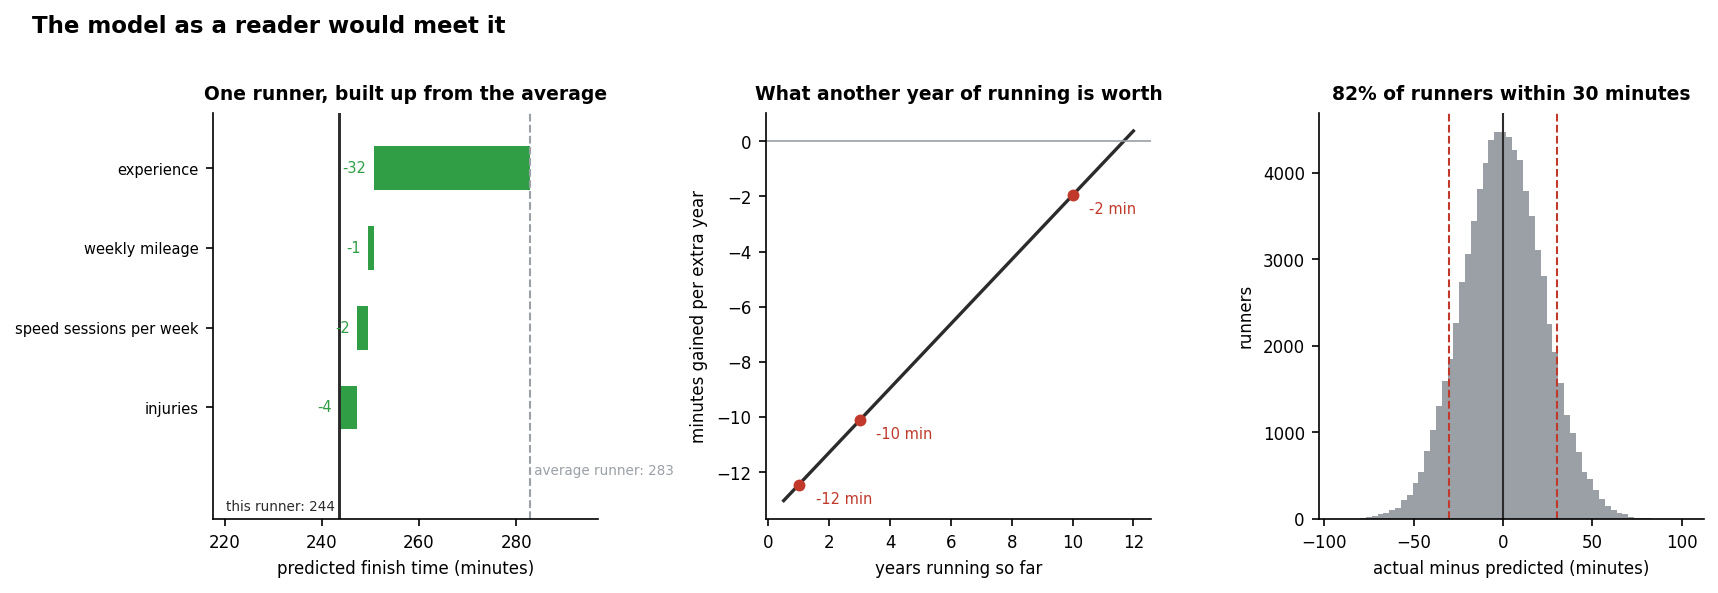

In [7]:
plt.rcParams.update({'figure.dpi': 150, 'font.size': 8, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 9, 'axes.titleweight': 'bold',
                     'axes.labelsize': 8, 'legend.frameon': False})
INK, ACC, GREY, POS = '#2b2b2b', '#c0392b', '#9aa0a6', '#2f9e44'
os.makedirs('../figures', exist_ok=True)

fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.8))

# A: waterfall for one example runner
r = typical.loc[3]
steps, labels = [], []
for c in PRED:
    if c == 'running_experience_months':
        delta = beta[1] * (r[c] - AVG[c]) + beta[-1] * (r[c] ** 2 - AVG[c] ** 2)
    else:
        delta = beta[PRED.index(c) + 1] * (r[c] - AVG[c])
    if abs(delta) >= 1:
        steps.append(delta); labels.append(SHORT.get(c, 'experience'))
a = ax[0]
run = REFERENCE
for i, (step, lab) in enumerate(zip(steps, labels)):
    a.barh(i, step, left=run, color=POS if step < 0 else ACC, height=0.55)
    a.text(min(run, run + step) - 1.5, i, f'{step:+.0f}', va='center', ha='right', fontsize=7,
           color=POS if step < 0 else ACC)
    run += step
a.axvline(REFERENCE, color=GREY, lw=1, ls='--')
a.axvline(run, color=INK, lw=1.4)
a.text(REFERENCE, len(labels) - 0.3, f' average runner: {REFERENCE:.0f}', fontsize=6.5, color=GREY, va='top')
a.text(run, len(labels) + 0.15, f'this runner: {run:.0f} ', fontsize=6.5, color=INK, va='top', ha='right')
a.set_yticks(range(len(labels))); a.set_yticklabels(labels, fontsize=7)
a.set_ylim(len(labels) + 0.4, -0.7)
a.set_xlim(run - 26, REFERENCE + 14)
a.set_title('One runner, built up from the average')
a.set_xlabel('predicted finish time (minutes)')

# B: value of another year, as a curve
a = ax[1]
ms = np.arange(6, 145)
a.plot(ms / 12, [experience_effect(m) for m in ms], color=INK, lw=1.6)
a.axhline(0, color=GREY, lw=0.8)
for m in (12, 36, 120):
    a.scatter(m / 12, experience_effect(m), s=22, color=ACC, zorder=3)
    a.annotate(f'{experience_effect(m):.0f} min', (m / 12, experience_effect(m)),
               textcoords='offset points', xytext=(8, -9), fontsize=7, color=ACC)
a.set_title('What another year of running is worth')
a.set_xlabel('years running so far'); a.set_ylabel('minutes gained per extra year')

# C: how wrong the model is
a = ax[2]
a.hist(resid, bins=60, color=GREY)
a.axvline(0, color=INK, lw=1)
for v in (-30, 30):
    a.axvline(v, color=ACC, ls='--', lw=1)
a.set_title(f'{(np.abs(resid) <= 30).mean():.0%} of runners within 30 minutes')
a.set_xlabel('actual minus predicted (minutes)'); a.set_ylabel('runners')

fig.suptitle('The model as a reader would meet it', fontsize=11, fontweight='bold',
             x=0.02, ha='left', y=1.02)
fig.tight_layout()
fig.savefig('../figures/fig4_plain_model.png', bbox_inches='tight')

## Save

In [8]:
effects.to_frame().to_csv('../data/effects_plain.csv')
years.to_csv('../data/experience_by_level.csv', index=False)
years

,experience,value of one more year
0,6 months,-13.0
1,1 year,-12.4
2,2 years,-11.3
3,3 years,-10.1
4,5 years,-7.8
5,10 years,-2.0


## Two cautions for whoever writes the text

**Quote a range, not a number.** An 18-minute average error means a prediction of 250 minutes is
"about 3h50 to 4h30". A single figure invites the reader to treat it as a training target.

**Never write that something has no effect.** VO2 max, BMI, age and previous marathon count all
land near zero here. The defensible sentence is that this dataset cannot detect an effect, not
that there is none. The dataset is synthetic and `03` showed 26 of 37 numeric columns are flat
against finish time, which points at how it was generated rather than at how running works. A
reader who takes "VO2 max does not matter" out of this report has been misled by us, not by the
data.